# Credit Card Fraud Detection

(Sample project using public data)

https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud

The dataset contains transactions made by credit cards in September 2013 by European cardholders.
This dataset presents transactions that occurred in *two days*, where we have 492 frauds out of 284,807 transactions. The dataset is highly unbalanced, the positive class (frauds) account for 0.172% of all transactions.

It contains only numerical input variables which are the result of a PCA transformation. Features V1, V2, ..., V28 are the principal components obtained with PCA. The only features which have not been transformed with PCA are 'Time' and 'Amount'. Feature 'Time' contains the seconds elapsed between each transaction and the first transaction in the dataset. The feature 'Amount' is the transaction Amount. Feature 'Class' is the response variable and it takes value 1 in case of fraud and 0 otherwise.

In [109]:

import numpy as np
import pandas as pd

SEED = 0

df = pd.read_csv('creditcard.csv')
df['hh'] = np.floor(df['Time'] // 3600).astype(int)
df = df.sort_values(by=['hh', 'Time']).reset_index(drop=True)
X, y = df.drop(columns=['Class']), df['Class']

display(df)

dfs = (
    pd.concat([df.loc[df['Class'] == 0].sample(frac=0.05, random_state=SEED),
               df.loc[df['Class'] == 1].sample(frac=1, random_state=SEED)])
    .reset_index(drop=True)
)
#Xs, ys = dfs.drop(columns=['Class']), dfs['Class']
Xs, ys = dfs[[c for c in dfs.columns if c[0] == 'V']], dfs['Class']



,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V22,V23,V24,V25,V26,V27,V28,Amount,Class,hh
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0,47
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0,47
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0,47
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0,47


## I. Data visualization

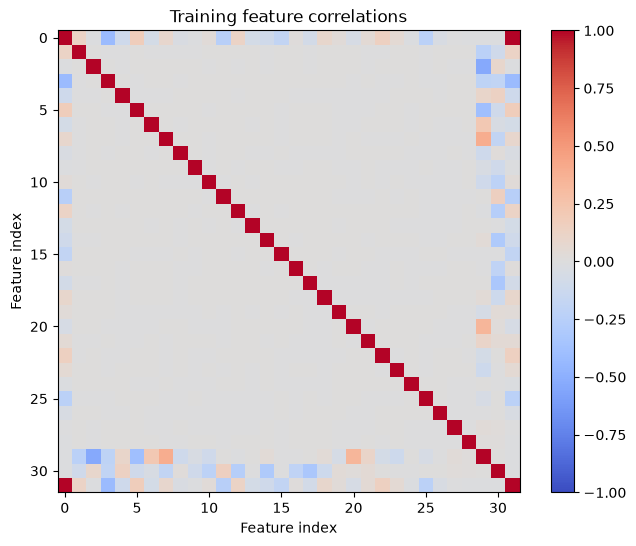

Time      47488.145955
V1            1.958696
V2            1.651309
V3            1.516255
V4            1.415869
V5            1.380247
V6            1.332271
V7            1.237094
V8            1.194353
V9            1.098632
V10           1.088850
V11           1.020713
V12           0.999201
V13           0.995274
V14           0.958596
V15           0.915316
V16           0.876253
V17           0.849337
V18           0.838176
V19           0.814041
V20           0.770925
V21           0.734524
V22           0.725702
V23           0.624460
V24           0.605647
V25           0.521278
V26           0.482227
V27           0.403632
V28           0.330083
Amount      250.120109
Class         0.041527
hh           13.184831
dtype: float64

In [110]:

import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(df.corr(), cmap='coolwarm', vmin=-1, vmax=1)
ax.set(title='Training feature correlations', xlabel='Feature index', ylabel='Feature index')
fig.colorbar(im, ax=ax)
plt.show()

display(df.std())


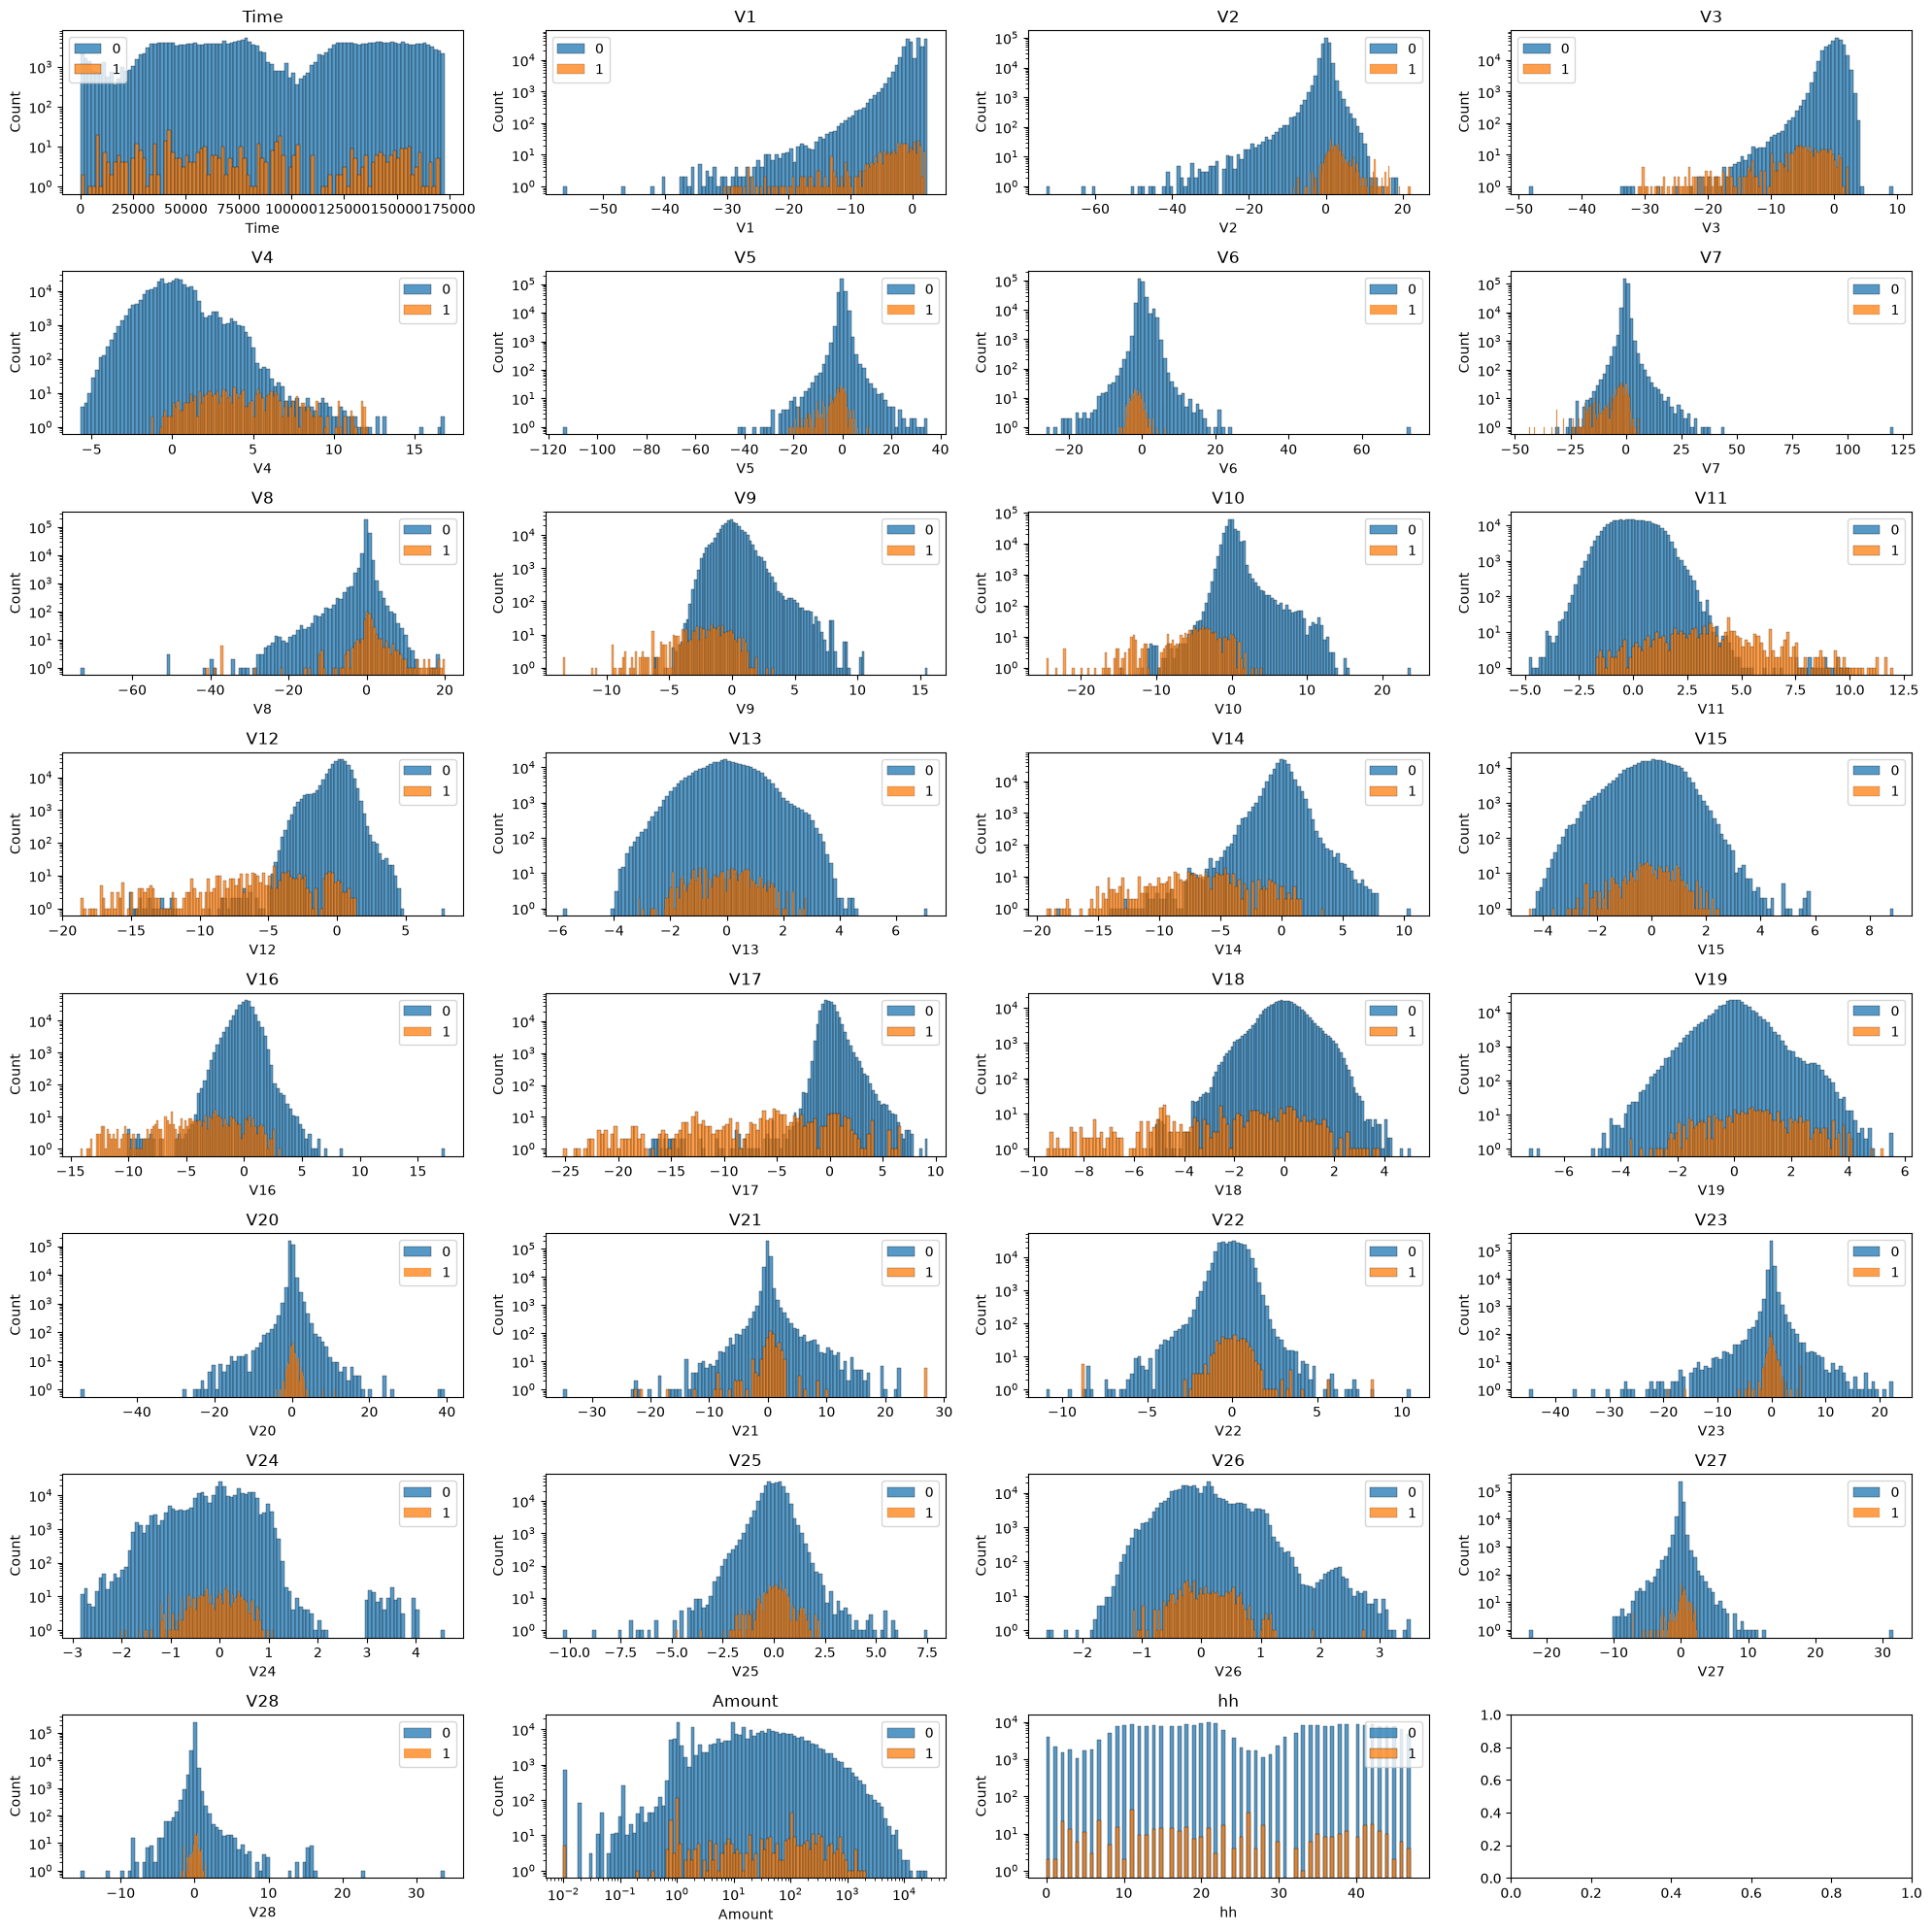

In [111]:

def hist_all(features, num_col=None, num_row=None):
    if num_row is None:
        if num_col is None:
            num_col = 4
        num_row = np.ceil(len(features) / num_col).astype('int')
    else:
        num_col = np.ceil(len(features) / num_row).astype('int')

    features = features.drop('Class')
    fig, ax = plt.subplots(num_row, num_col, figsize=(20, 20))
    i = 0
    for feature in features:
        i += 1
        plt.subplot(num_row, num_col, i)
        log_scale = (feature in ['Amount'])
        sns.histplot(df[df['Class']==0][feature], bins=100, label='0', log_scale=log_scale)
        sns.histplot(df[df['Class']==1][feature], bins=100, label='1', log_scale=log_scale)
        plt.title(feature)
        plt.yscale('log')
        plt.legend()
    fig.tight_layout()
    plt.show()

hist_all(df.select_dtypes(["int", "float"]).columns, num_col=4)



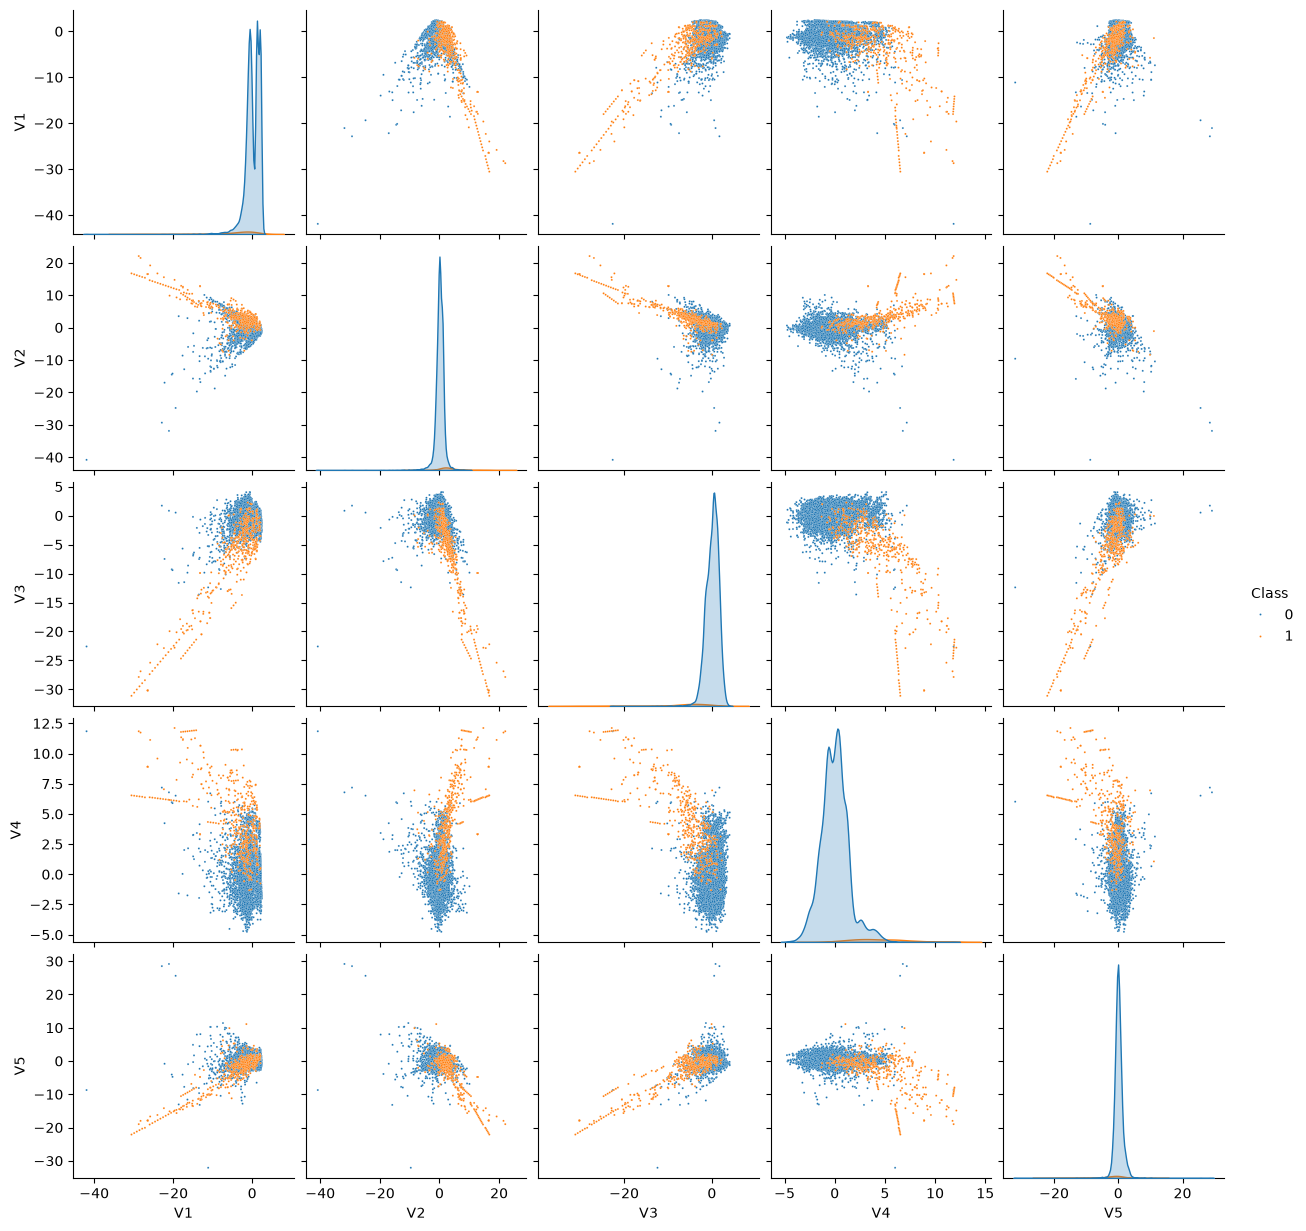

In [112]:

sns.pairplot(dfs[['V'+str(i) for i in range(1,6)] + ['Class']], hue='Class', plot_kws={'s': 2})
plt.show()


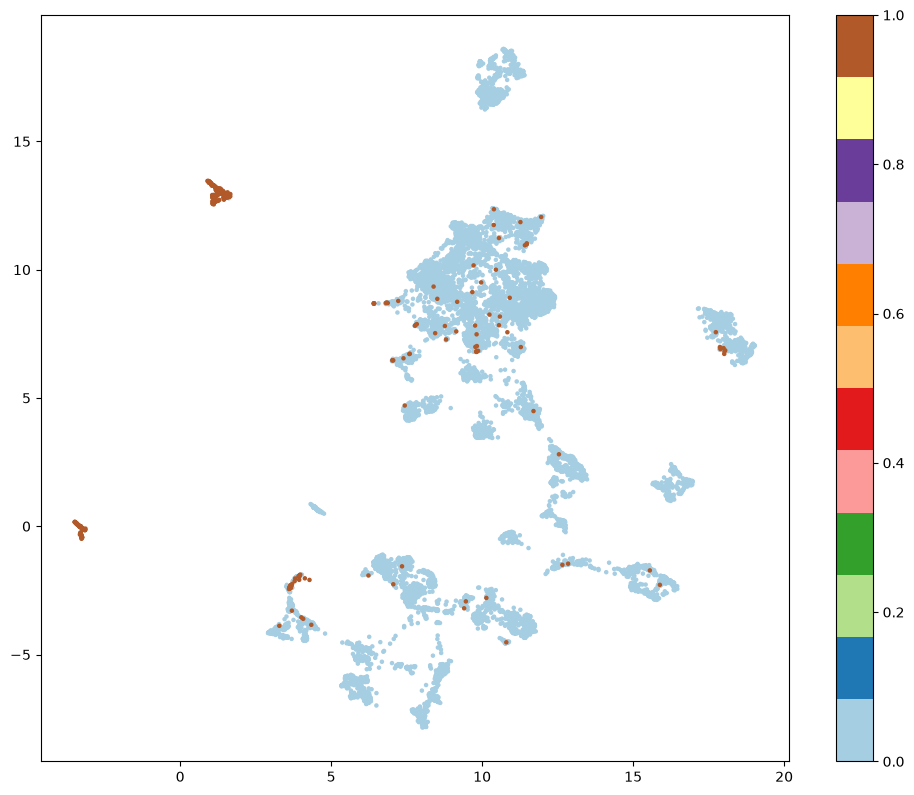

Class  neg
0      0      14215
1      0        385
       1        107
0      1          1
Name: count, dtype: int64

In [114]:

from umap import UMAP
import matplotlib.pyplot as plt

# (100, 0-0.3) worked well, isolating a cluster with (3, 381)
reducer = UMAP(
    n_components=2,
    n_neighbors=50,
    min_dist=0.1,
    metric="euclidean",
    random_state=SEED,
    n_jobs=1,
)
embedding = reducer.fit_transform(Xs)

plt.figure(figsize=(10, 8))
plt.scatter(embedding[:, 0], embedding[:, 1], c=ys, cmap='Paired', s=5)
plt.tight_layout()
plt.colorbar()
plt.show()

emb = pd.concat([pd.DataFrame(embedding), ys], axis=1)
emb['neg'] = (emb[0] < 0).astype(int)
#sns.histplot(emb[0])
emb[['Class', 'neg']].value_counts()


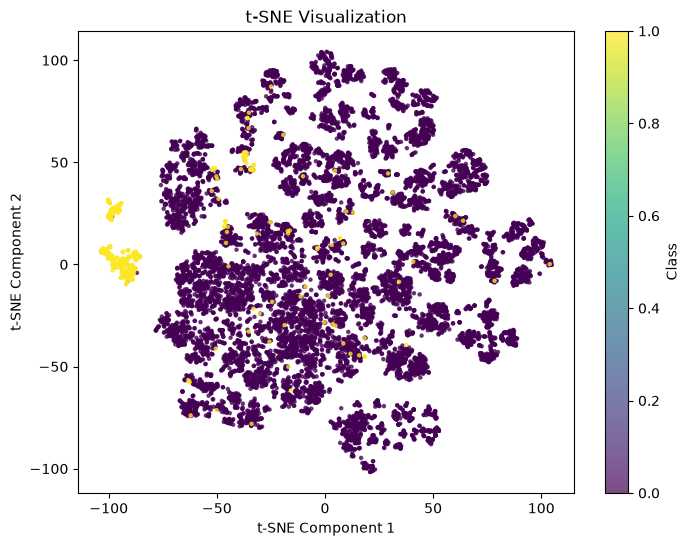

In [ ]:

import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30.0,         # Balance between local and global data structures (5-50)
    learning_rate="auto",    # Step size for gradient descent optimization
    init="pca",              # Initialization strategy ('pca' preserves global structure better)
    random_state=SEED,
    n_jobs=-2
)

dfs = pd.concat([df.loc[df['Class'] == 0].sample(frac=0.05, random_state=SEED),
                 df.loc[df['Class'] == 1]])

Xs, ys = dfs.drop(columns=['Class']), dfs['Class']
Xs_tsne = tsne.fit_transform(Xs[[c for c in Xs.columns if c[0] == 'V']])

# 4. Visualize the cluster results
plt.figure(figsize=(8, 6))
scatter = plt.scatter(Xs_tsne[:, 0], Xs_tsne[:, 1], c=ys, cmap="viridis", alpha=0.7, s=5)
plt.colorbar(scatter, label="Class")
plt.title("t-SNE Visualization")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.show()


## II. Sample split and cross validation strategy

- Instead of taking a randomized K-Fold cross validation, I chose a time series cross validation to avoid any potential leakage.
- To mimic the production environment, instead of splitting based on the number of samples (which would be the default when using the built-in function TimeSeriesSplit), I chose to split based on the time window by writing a custom split function.
- My preferred specification is the rolling window approach with the fixed window length for the training data, but the expanding set of training data with fixed start time can be chosen by setting the variable rolling = False.

In my default specification, among the 48 hours of data, the first 24 hours will be used only for training, and the remaining 24 hours is divided into validation (20 = 5 x 4) and testing (4). For example,
- The 1st fold uses as training the first 24 hour window between 00:00 and 24:00 and uses for validation the next 4 hours between 24:00 and 28:00.
- The final test data uses 20:00 to 44:00 for training and 44:00 to 48:00 for testing.


In [116]:

from sklearn.model_selection import StratifiedKFold

def train_test_split_custom(X, y, test_size):
    start_hh = X['hh'].min()
    end_hh = X['hh'].max() + 1
    range_hh = end_hh - start_hh
    test_len = int(np.ceil(range_hh * test_size))
    train_len = range_hh - test_len
    X_train, X_test = X[X['hh'] < start_hh + train_len], X[X['hh'] >= start_hh + train_len]
    y_train, y_test = y[X['hh'] < start_hh + train_len], y[X['hh'] >= start_hh + train_len]
    
    return X_train, X_test, y_train, y_test


def TimeSeriesSplit_custom(X, y, n_splits, test_size, delay_hh=0, rolling=True):
    start_hh = X['hh'].min()
    end_hh = X['hh'].max() + 1
    range_hh = end_hh - start_hh
    test_len = int(np.ceil(range_hh * test_size))
    train_len = range_hh - test_len * n_splits - delay_hh

    splits = []
    for i in range(n_splits):
        train_mask = (
            (X['hh'] >= start_hh + test_len * np.where(rolling, i, 0)) &
            (X['hh'] < start_hh + test_len * i + train_len)
        )

        test_mask = (
            (X['hh'] >= start_hh + test_len * i + train_len + delay_hh) &
            (X['hh'] < start_hh + test_len * (i + 1) + train_len + delay_hh)
        )

        train_idx = np.flatnonzero(train_mask.to_numpy())
        test_idx = np.flatnonzero(test_mask.to_numpy())

        splits.append((train_idx, test_idx))
    
    return splits


# handles the split of the final test dataset
def TimeSeriesSplit_custom_final(X, y, n_splits, test_size, delay_hh=0, rolling=True):
    return TimeSeriesSplit_custom(
        X, y, n_splits=n_splits+1, test_size=test_size, delay_hh=delay_hh, rolling=rolling)[-1]


SEED = 0
tss_op = {
    'n_splits': 5,
    'test_size': 0.08,
    'delay_hh': 0
}
rolling = True

X_train, X_test, y_train, y_test = train_test_split_custom(X, y, test_size=tss_op['test_size'])
cv = TimeSeriesSplit_custom(X_train, y_train, **tss_op, rolling=rolling)
cv_final = TimeSeriesSplit_custom_final(X, y, **tss_op, rolling=rolling)

train_idx, test_idx = cv_final
Xf_train = X.iloc[train_idx]
yf_train = y.iloc[train_idx]



Generate an auxiliary dataframe that summarizes each CV fold. The last row corresponds to the final test set.

In [117]:

# returns a dict that summarizes the current CV fold
def split_summary(X, y, train_idx, test_idx):
    return {
        'train_sample': len(y.iloc[train_idx]),
        'test_sample': len(y.iloc[test_idx]),
        'train_positives': y.iloc[train_idx].sum(),
        'test_positives': y.iloc[test_idx].sum(),
        'train_pos_rate': y.iloc[train_idx].mean(),
        'test_pos_rate': y.iloc[test_idx].mean(),
        'train_hh_min': X.iloc[train_idx]['hh'].min(),
        'train_hh_max': X.iloc[train_idx]['hh'].max(),
        'test_hh_min': X.iloc[test_idx]['hh'].min(),
        'test_hh_max': X.iloc[test_idx]['hh'].max(),
        'train_idx_min': train_idx.min(),
        'train_idx_max': train_idx.max(),
        'test_idx_min': test_idx.min(),
        'test_idx_max': test_idx.max(),
    }


cv_sum = []

for i in range(len(cv)):
    train_idx_, test_idx_ = cv[i]
    cv_sum += [{
        'fold': i,
        **split_summary(X_train, y_train, train_idx_, test_idx_)
    }]

cv_sum += [{
    'fold': tss_op['n_splits'],
    **split_summary(X, y, train_idx, test_idx)
}]

cv_sum = pd.DataFrame(cv_sum)
display(cv_sum)



,fold,train_sample,test_sample,train_positives,test_positives,train_pos_rate,test_pos_rate,train_hh_min,train_hh_max,test_hh_min,test_hh_max,train_idx_min,train_idx_max,test_idx_min,test_idx_max
0,0,144786,9158,281,52,0.001941,0.005678,0,23,24,27,0,144785,144786,153943
1,1,144367,8581,295,23,0.002043,0.002680,4,27,28,31,9577,153943,153944,162524
2,2,144986,29706,275,21,0.001897,0.000707,8,31,32,35,17539,162524,162525,192230
3,3,144830,32634,231,38,0.001595,0.001164,12,35,36,39,47401,192230,192231,224864
4,4,146282,33038,224,55,0.001531,0.001665,16,39,40,43,78583,224864,224865,257902
5,5,147051,26904,231,22,0.001571,0.000818,20,43,44,47,110852,257902,257903,284806


## III. Choice of the evaluation metric

Given the severe imbalance in the fraud data, the evaluation metric needs to be chosen carefully. The list of candidates being considered are:
- AUC-ROC
- Average Precision (similar and potentially better than AUC-PR)
- precision/recall @ k.

Among these, my preferred choice is recall @ 1%.
- As opposed to AUC metrics, @ k metrics focuses on the specific point on the curve that is most relevant.
- In practice, the actual review capacity would determine k in terms of number of cases (not the share). Here, 1% is chosen for convenience in the lack of such information.
- While both precision and recall contain similar information (and identical info for the choice of best model), my preference is recall. In the ideal case of covering all true positives (especially given 1% >> 0.17%), recall = 0.17% / 0.17% = 1, whereas precision = 0.17% / 1% = 0.17 which depends on the denominator (k).
- Given the use of % as k, the two are equivalent. Note that if the number of cases is used as k, the two would have different implications upon aggregation. Precision @ k would give equal weight to each positive label, whereas recall @ k would give equal weight to each time window.



In [118]:

from sklearn.metrics import get_scorer, make_scorer

def recall_at_k_pct(y_true, y_scores, p):
    y_true = np.asarray(y_true)
    if np.sum(y_true) == 0:
        return 0.0
    
    k = int(len(y_true) * p)
    order = np.argsort(y_scores)[::-1]
    y_true_sorted = y_true[order][:k]
    return np.sum(y_true_sorted) / np.sum(y_true)


recall_at_10p = make_scorer(
    recall_at_k_pct,
    response_method="predict_proba",
    p=0.1
)

recall_at_1p = make_scorer(
    recall_at_k_pct,
    response_method="predict_proba",
    p=0.01
)

custom_scorer = {
    'roc_auc': 'roc_auc',
    'ap': 'average_precision',
    'rec_10p': recall_at_10p,
    'rec_1p': recall_at_1p,
}


## IV. Choice of models and pipelines

Given the tabular nature of the dataset, I started with logistic regression, random forest, and XGBoost. For the logistic regression, standard scaler is applied before the model (not needed for tree based models). The current dataset does not have any missing values, so the imputer is not used.

In [ ]:

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import ParameterSampler, ParameterGrid

from umap import UMAP
from umap_u import UnsupervisedUMAP

'''
# [umap_u.py]
# placed in a separate file to enable caching of the pipeline
class UnsupervisedUMAP(UMAP):
    def fit(self, X, y=None, *args, **kwargs):
        return super().fit(X, None, *args, **kwargs)

    def fit_transform(self, X, y=None, *args, **kwargs):
        return super().fit_transform(X, None, *args, **kwargs)
'''

def reducer_umap(supervised=False, **kwargs):
    params = dict(n_components=2, n_neighbors=30, min_dist=0.1,
                  metric='euclidean', random_state=SEED, n_jobs=1, n_epochs=200)
    params.update(kwargs)
    return (UMAP if supervised else UnsupervisedUMAP)(**params)


umap_configs = list(ParameterGrid({
    "umap__n_neighbors": [50],
    "umap__min_dist": [0.1],
    "umap__n_components": [2, 10],
}))

clf_grid = {
    "lr": {
        "clf__C": np.logspace(-4, 4, 81),
        "clf__class_weight": [None, "balanced"],
    },
    "rf": {
        "clf__n_estimators": [100, 200],
        "clf__max_depth": [5, 7, 10, 15, 20],
        "clf__min_samples_split": [2, 5, 10, 20],
        "clf__min_samples_leaf": [1, 2, 4, 8],
        "clf__max_features": ["sqrt", "log2", 0.5],
        "clf__class_weight": [None, "balanced"],
    },
    "xgb": {
        "clf__n_estimators": [100, 200, 300, 500],
        "clf__max_depth": [3, 4, 5, 6, 8, 10],
        "clf__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
        "clf__subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
        "clf__colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
        "clf__min_child_weight": [1, 3, 5, 7, 10],
        "clf__gamma": [0, 0.1, 0.2, 0.5, 1],
        "clf__reg_alpha": [0, 0.01, 0.1, 1],
        "clf__reg_lambda": [0.1, 1, 5, 10],
        "clf__scale_pos_weight": [1, 2, 5, 10],
    },
}

n_iter = 2
clf_configs = {}
for name in clf_grid.keys():
    clf_configs[name] = list(ParameterSampler(
        clf_grid[name],
        n_iter=n_iter,
        random_state=SEED,
    ))

candidates = {}
for name in clf_grid.keys():
    candidates[name] = [
        {key: [value] for key, value in {**c}.items()}
        for c in clf_configs[name]
    ]
    candidates[name+'_umap'] = [
        {key: [value] for key, value in {**c, **u}.items()}
        for c in clf_configs[name]
        for u in umap_configs
    ]


def gen_clf(name):
    if name == "lr":
        return [('clf', LogisticRegression(max_iter=2000, random_state=SEED))]
    elif name == "rf":
        return [('clf', RandomForestClassifier(random_state=SEED))]
    elif name == "xgb":
        return [('clf', XGBClassifier(random_state=SEED))]
    return None


from joblib import Memory
cache = Memory(location="./pipeline_cache")

pipe = {}
for name in clf_grid.keys():
    _pipe = [('scale', StandardScaler())]
    _pipe += gen_clf(name)
    pipe[name] = Pipeline(_pipe, memory=cache)

    _pipe = [('scale', StandardScaler()), ('umap', reducer_umap())]
    _pipe += gen_clf(name)
    pipe[name+'_umap'] = Pipeline(_pipe, memory=cache)



In [151]:

import pickle
import joblib
reducer = pipe['lr_umap'].named_steps["umap"]

pickle.dumps(reducer)           # Should succeed
print(joblib.hash(reducer))     # Should produce a cache fingerprint


04c1505a28254d17eb6a743c5f7e054e


## V. Hyperparameter search using RandomizedSearchCV

In [152]:

import time
from sklearn.model_selection import GridSearchCV

refit_metric_list = ['rec_1p']

# May turn off refit to reduce execution time while debugging
refit_after_search = True

res_all = pd.DataFrame()
start_all = time.time()

for name in pipe.keys():
    start = time.time()
    search = GridSearchCV(
        pipe[name],
        param_grid=candidates[name],
        scoring=custom_scorer,
        refit=False,
        cv=cv, n_jobs=-2,
        error_score="raise",
    )
    search.fit(X_train, y_train)
    end = time.time()
    print(f"search in {name}: {end - start} seconds")

    res = pd.DataFrame(search.cv_results_)
    res['name'] = name
    res['iter'] = res.index
    
    # exclude the columns that begin with 'param_' since that info is already in the column 'param'
    res_all = pd.concat([res_all, res[[c for c in res.columns if c[:6] != 'param_']]], ignore_index=True)

end_all = time.time()
print(f"search total: {end_all - start_all} seconds")

cols_order = (
    ['name', 'iter', 'params'] +
    [c for c in res_all.columns if c[:4] in ['rank', 'mean', 'std_'] and c[-4:] != 'time']
)

res_all = res_all[cols_order + [c for c in res_all.columns if c not in cols_order]]
display(res_all.round(4))


search in lr: 3.925659656524658 seconds
search in lr_umap: 1277.5133261680603 seconds
search in rf: 185.77744579315186 seconds
search in rf_umap: 197.121080160141 seconds
search in xgb: 21.682463884353638 seconds
search in xgb_umap: 102.88085436820984 seconds
search total: 1789.0689017772675 seconds


,name,iter,params,mean_test_roc_auc,std_test_roc_auc,rank_test_roc_auc,mean_test_ap,std_test_ap,rank_test_ap,mean_test_rec_10p,...,split0_test_rec_10p,split1_test_rec_10p,split2_test_rec_10p,split3_test_rec_10p,split4_test_rec_10p,split0_test_rec_1p,split1_test_rec_1p,split2_test_rec_1p,split3_test_rec_1p,split4_test_rec_1p
0,lr,0,"{'clf__C': 0.19952623149688808, 'clf__class_we...",0.9631,0.0274,2,0.7670,0.0645,2,0.9057,...,0.9615,0.8696,0.8571,0.8947,0.9455,0.7885,0.7826,0.8571,0.8158,0.9091
1,lr,1,"{'clf__C': 316.22776601683796, 'clf__class_wei...",0.9692,0.0155,1,0.8017,0.0594,1,0.9300,...,0.9038,0.9565,0.9048,0.9211,0.9636,0.8462,0.8696,0.9048,0.8684,0.8909
2,lr_umap,0,"{'clf__C': 0.19952623149688808, 'clf__class_we...",0.8520,0.0712,4,0.4125,0.2796,3,0.7138,...,0.5962,0.6957,0.7143,0.7632,0.8000,0.5962,0.6957,0.6667,0.0000,0.6364
3,lr_umap,1,"{'clf__C': 0.19952623149688808, 'clf__class_we...",0.8645,0.0549,2,0.6317,0.0645,1,0.7082,...,0.6154,0.6957,0.6667,0.7632,0.8000,0.5962,0.6957,0.6667,0.6579,0.7455
4,lr_umap,2,"{'clf__C': 316.22776601683796, 'clf__class_wei...",0.8612,0.0617,3,0.4121,0.2790,4,0.7138,...,0.5962,0.6957,0.7143,0.7632,0.8000,0.5962,0.6957,0.6667,0.0000,0.6364
5,lr_umap,3,"{'clf__C': 316.22776601683796, 'clf__class_wei...",0.8719,0.0580,1,0.6168,0.0536,2,0.7448,...,0.6154,0.7391,0.7619,0.7895,0.8182,0.5962,0.6957,0.7143,0.6053,0.7455
6,rf,0,"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9704,0.0187,2,0.8024,0.0620,1,0.9140,...,0.9423,0.9565,0.8571,0.8684,0.9455,0.8846,0.8696,0.8571,0.8421,0.9273
7,rf,1,"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9807,0.0097,1,0.7308,0.1089,2,0.9453,...,0.9808,0.9565,0.9048,0.9211,0.9636,0.8654,0.7391,0.8095,0.8158,0.9273
8,rf_umap,0,"{'clf__class_weight': 'balanced', 'clf__max_de...",0.8939,0.0306,4,0.5850,0.0784,1,0.7630,...,0.6346,0.7826,0.7619,0.7632,0.8727,0.5577,0.6957,0.7143,0.7632,0.7273
9,rf_umap,1,"{'clf__class_weight': 'balanced', 'clf__max_de...",0.9295,0.0125,1,0.5647,0.0930,3,0.8104,...,0.9038,0.8261,0.7143,0.7895,0.8182,0.5577,0.6957,0.7143,0.7105,0.6727


### Collect the best set of parameters for each metric (if refit_after_search = True)

If refit_after_search = False, just use the first set of parameters from search.



In [153]:
from sklearn.base import clone

pipe_test = {}
model = {}
param_dic = {}
res_sum = pd.DataFrame()
start_all = time.time()

for name in pipe.keys():
    param_dic = {'name': name}
    start = time.time()
    metric = refit_metric_list[0]
    model_res = res_all.loc[res_all['name'] == name].reset_index(drop=True)
    
    idx = model_res.index[np.argmax(model_res['mean_test_'+metric].values)] if refit_after_search else 0

    param = model_res['params'].iloc[idx]
    param_dic['param_'+metric] = param
    param_dic['cv_mean_'+metric] = model_res['mean_test_'+metric].iloc[idx]
    param_dic['cv_std_'+metric] = model_res['std_test_'+metric].iloc[idx]
    
    pipe_test[name] = clone(pipe[name]).set_params(**param)
    pipe_test[name].fit(Xf_train, yf_train)
    model[name] = pipe_test[name]['clf']
    
    scorer_key = custom_scorer[metric]
    scorer = get_scorer(scorer_key) if isinstance(scorer_key, str) else scorer_key
    score = scorer(pipe_test[name], X_test, y_test)
    param_dic['test_'+metric] = score
    
    res_sum = pd.concat([res_sum, pd.DataFrame([param_dic])], ignore_index=True)
    end = time.time()
    print(f"final fit in {name}: {end - start} seconds")

end_all = time.time()
print(f"final fit total: {end_all - start_all} seconds")
display(res_sum)



[Memory]0.2s, 0.0min    : Loading _fit_transform_one_with_callbacks from ./pipeline_cache\joblib\sklearn\pipeline\_fit_transform_one_with_callbacks\3a51d3922d34531183b710e811515510
____________________fit_transform_one_with_callbacks cache loaded - 0.0s, 0.0min
final fit in lr: 1.440911054611206 seconds
[Memory]0.0s, 0.0min    : Loading _fit_transform_one_with_callbacks from ./pipeline_cache\joblib\sklearn\pipeline\_fit_transform_one_with_callbacks\3a51d3922d34531183b710e811515510
____________________fit_transform_one_with_callbacks cache loaded - 0.0s, 0.0min
________________________________________________________________________________
[Memory] Calling sklearn.pipeline._fit_transform_one_with_callbacks...
_fit_transform_one_with_callbacks(UnsupervisedUMAP(n_components=10, n_epochs=200, n_jobs=1, n_neighbors=50, random_state=0), 
array([[-1.736062, ..., -1.674767],
       ...,
       [ 1.42286 , ...,  1.358853]], shape=(147051, 31)), 
110852    0
110853    0
110854    0
110855    0


,name,param_rec_1p,cv_mean_rec_1p,cv_std_rec_1p,test_rec_1p
0,lr,"{'clf__C': 316.22776601683796, 'clf__class_wei...",0.875962,0.020195,0.772727
1,lr_umap,"{'clf__C': 0.19952623149688808, 'clf__class_we...",0.672364,0.048856,0.500000
2,rf,"{'clf__class_weight': 'balanced', 'clf__max_de...",0.876140,0.029151,0.727273
3,rf_umap,"{'clf__class_weight': 'balanced', 'clf__max_de...",0.691612,0.070506,0.500000
4,xgb,"{'clf__colsample_bytree': 1.0, 'clf__gamma': 0...",0.884247,0.038880,0.727273
5,xgb_umap,"{'clf__colsample_bytree': 0.7, 'clf__gamma': 0...",0.711427,0.069669,0.545455


## VI. Visualization of the result

### 1. Feature importance plot (for tree-based models)

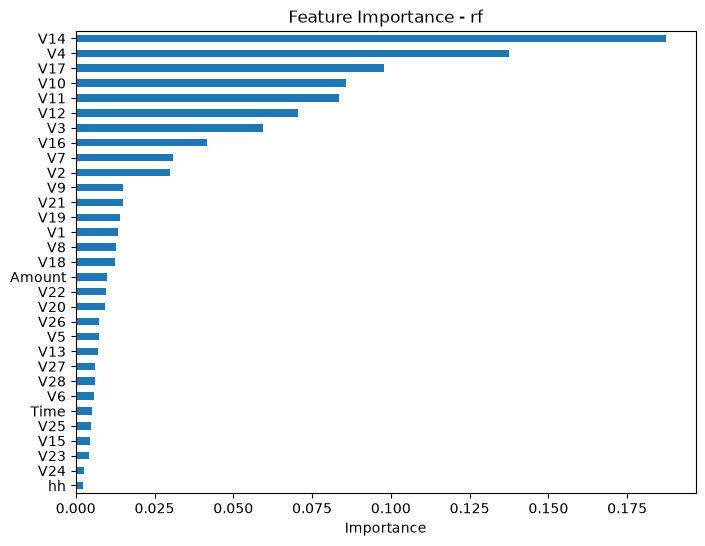

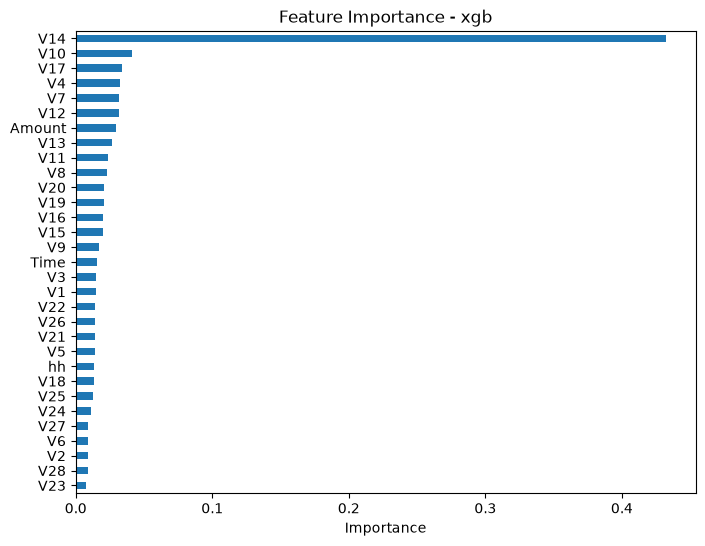

In [154]:

import matplotlib.pyplot as plt

tree_model_list = [name for name in pipe.keys() if name[:2] != 'lr' and name[-4:] != 'umap']

for name in tree_model_list:
    importance = pd.Series(
        model[name].feature_importances_,
        index=X_train.columns
    ).sort_values()

    importance.plot.barh(figsize=(8, 6))
    plt.xlabel("Importance")
    plt.title(f"Feature Importance - {name}")
    plt.show()


### 2. SHAP beeswarm plot (for tree-based models)

rf


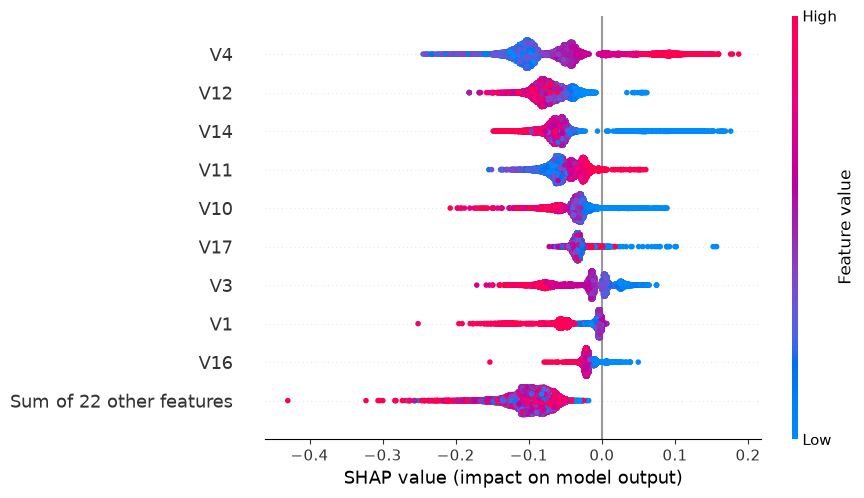

xgb


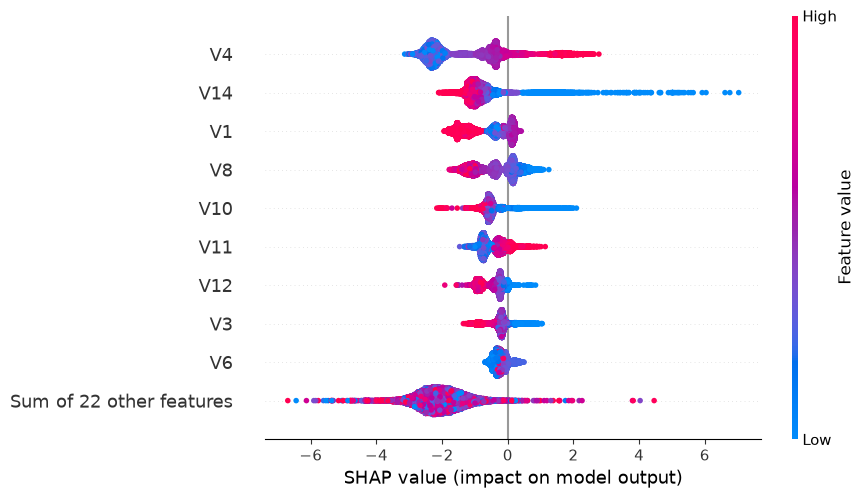

In [158]:

import shap

explainer = {name: shap.TreeExplainer(model[name]) for name in tree_model_list}
shap_values = {name: explainer[name](X_test) for name in tree_model_list}

for name in tree_model_list:
    explainer[name] = shap.TreeExplainer(model[name])
    shap_values[name] = explainer[name](X_test)

    print(name)
    if name == 'rf':
        shap.plots.beeswarm(shap_values[name][:,:,1])
    else:
        shap.plots.beeswarm(shap_values[name])



### 3. Partial dependence plot (for all models)

lr


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('clf', ...)]"
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(locati..._cache\joblib)
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['Time','V1','V2',...,'V28','Amount','hh']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


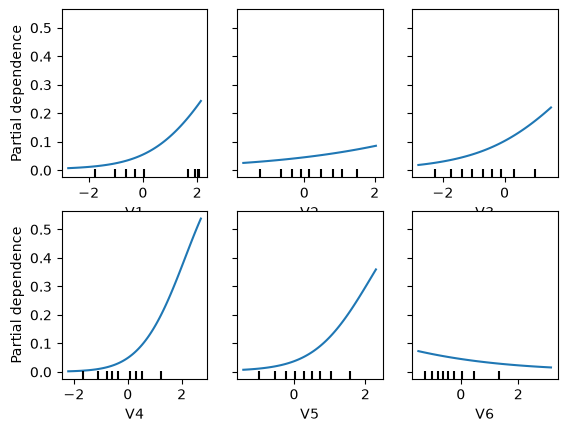

rf


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('clf', ...)]"
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(locati..._cache\joblib)
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['Time','V1','V2',...,'V28','Amount','hh']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


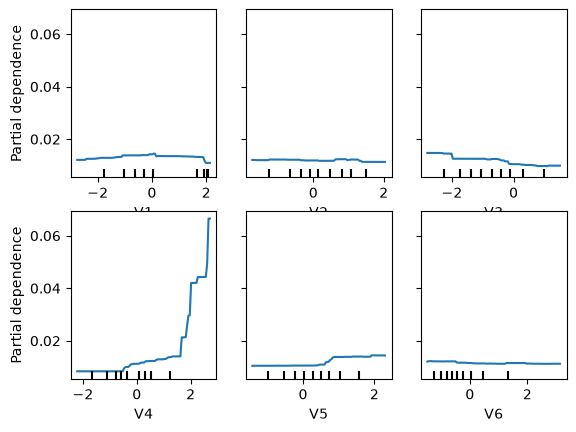

xgb


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scale', ...), ('clf', ...)]"
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",Memory(locati..._cache\joblib)
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](31,)","['Time','V1','V2',...,'V28','Amount','hh']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,31
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


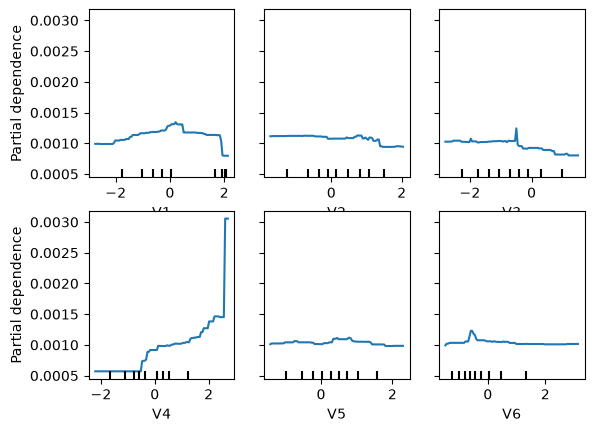

In [159]:

from sklearn.inspection import PartialDependenceDisplay

for name in pipe.keys():
    if name[-4:] != 'umap':
        PartialDependenceDisplay.from_estimator(
            pipe_test[name],
            X_test,
            ["V1", "V2", "V3", "V4", "V5", "V6"]
        )
        print(name)
        display(pipe_test[name])
        plt.show()


### (In progress)

In [ ]:

from hidimstat import LOCO
from sklearn.ensemble import RandomForestRegressor

ablation = LOCO(
    estimator=model['xgb'],
    n_jobs=-1,
)

ablation.fit(Xf_train, yf_train)
importances = ablation.importance(X_test, y_test)

df_loco = pd.DataFrame(
    {
        "feature": list(range(X.shape[1])),
        "importance": importances,
        "model": model['xgb'].__class__.__name__,
        "R2 score": model['xgb'].score(X_test, y_test),
    }
)

print(df_loco)


In [ ]:

import statsmodels.formula.api as smf

ols = {}
ols[0] = smf.ols(formula="Class ~ 1", data=df).fit()
ols[1] = smf.ols(formula="Class ~ V14", data=df).fit()
ols[2] = smf.ols(formula="Class ~ V14 + V4", data=df).fit()
ols[3] = smf.ols(formula="Class ~ V14 + V4 + V17", data=df).fit()
for i in range(4):
    print(ols[i].summary())

